# MindSafe: Empirical Statistical & Inferential Analysis
**Project:** MindSafe — An AI-Based Cyberbullying & Its Impact on Mental Health  
**Study Type:** Empirical Quantitative Survey Analysis ($N = 519$)  
**Pipeline Phase:** Phase 2 — Comprehensive Statistical Analysis, Hypothesis Testing, Assumption Validation, and Effect Size Estimation  

---

### Methodological Principles & Scientific Scope:
1. **Primary Empirical Grounding:** All calculations are conducted strictly on the preprocessed primary survey dataset. No simulated, synthetic, or imputed artificial records are used.
2. **Assumption-First Testing Protocol:** Every inferential procedure explicitly verifies formal assumptions (Normality via Shapiro-Wilk and Q-Q plots, Homoscedasticity via Levene's test, Contingency cell counts $\ge 5$). When assumptions are violated, non-parametric alternatives (Mann-Whitney U, Kruskal-Wallis, Fisher's Exact) are reported alongside.
3. **Statistical Significance vs Effect Size:** P-values quantify evidence against the null hypothesis, whereas effect sizes (Cramér's $V$, Cohen's $d$, Eta-squared $\eta^2$, Spearman $ho$) measure the practical magnitude of associations. Both are systematically reported.
4. **False Discovery Rate (FDR) Control:** Multiple simultaneous hypothesis tests are adjusted using the Benjamini-Hochberg procedure to prevent Type I error inflation.
5. **Non-Causal Academic Demarcation:** In strict accordance with academic research standards, all relationships describe observed statistical associations. No claims of medical diagnosis, psychiatric evaluation, or causal proof are made.

## 1. Import Libraries
Load standard scientific computing, statistical analysis, and data visualization packages.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
from scipy import stats
import itertools

# Matplotlib configuration for publication quality
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.get
import matplotlib.pyplot as plt

# Presentation and tabular formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
plt.style.use('default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 150

# Ensure output directories exist
for p in [os.path.join('..', 'results', 'figures'), os.path.join('results', 'figures'),
          os.path.join('..', 'Data', 'processed'), os.path.join('Data', 'processed')]:
    os.makedirs(p, exist_ok=True)

print("Statistical analysis environment initialized.")

Statistical analysis environment initialized.


## 2. Load Processed Dataset
Load the cleaned primary survey dataset (`cleaned_survey_data.csv`).

In [2]:
candidates = [
    os.path.join('..', 'Data', 'processed', 'cleaned_survey_data.csv'),
    os.path.join('Data', 'processed', 'cleaned_survey_data.csv'),
    os.path.join(os.getcwd(), 'Data', 'processed', 'cleaned_survey_data.csv'),
    os.path.join(os.path.dirname(os.getcwd()), 'Data', 'processed', 'cleaned_survey_data.csv')
]

data_path = None
for c in candidates:
    if os.path.exists(c):
        data_path = c
        break

if not data_path:
    raise FileNotFoundError("Could not find cleaned_survey_data.csv in designated directories.")

print(f"Loading cleaned dataset from: {data_path}")
df_raw = pd.read_csv(data_path, encoding='utf-8', keep_default_na=False)

# Normalize empty strings while preserving legitimate 'None' values
col13_name = df_raw.columns[13]
for col in df_raw.columns:
    if col != col13_name:
        df_raw[col] = df_raw[col].replace({'': np.nan})
    else:
        df_raw[col] = df_raw[col].apply(lambda x: np.nan if x == '' else x)

print(f"Successfully loaded dataset: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

Loading cleaned dataset from: ..\Data\processed\cleaned_survey_data.csv
Successfully loaded dataset: 521 rows × 19 columns


## 3. Dataset Overview
Examine dataset dimensions, data types, missing values, duplicate submissions, and variable counts.

In [3]:
num_initial_rows, num_variables = df_raw.shape
duplicate_count = df_raw.duplicated().sum()

overview_metrics = {
    'Total_Recorded_Submissions': num_initial_rows,
    'Total_Survey_Variables': num_variables,
    'Duplicate_Rows': duplicate_count,
    'Memory_Usage_KB': round(df_raw.memory_usage().sum() / 1024, 2)
}
display(pd.DataFrame([overview_metrics]))

# Detailed variable inventory
var_inventory = []
for idx, col in enumerate(df_raw.columns):
    var_inventory.append({
        'Index': idx,
        'Variable_Name': col,
        'Data_Type': str(df_raw[col].dtype),
        'Non_Null_Count': df_raw[col].notna().sum(),
        'Missing_Count': df_raw[col].isna().sum(),
        'Missing_Percentage (%)': round(df_raw[col].isna().sum() / len(df_raw) * 100, 2),
        'Unique_Categories': df_raw[col].nunique()
    })

df_inventory = pd.DataFrame(var_inventory)
display(df_inventory)

,Total_Recorded_Submissions,Total_Survey_Variables,Duplicate_Rows,Memory_Usage_KB
0,521,19,0,77.460


,Index,Variable_Name,Data_Type,Non_Null_Count,Missing_Count,Missing_Percentage (%),Unique_Categories
0,0,Timestamp,object,521,0,0.000,502
1,1,[SECTION A: Basic Information] 1. What is your...,object,519,2,0.380,6
2,2,2. What is your gender?,object,519,2,0.380,4
3,3,[SECTION B: Social Media Usage] 3. Which socia...,object,519,2,0.380,15
4,4,4. How many hours do you spend on social media...,object,519,2,0.380,4
5,5,[SECTION C: Cyberbullying Experience] 5. Have ...,object,518,3,0.580,2
6,6,6. Have you ever witnessed someone being cyber...,object,519,2,0.380,2
7,7,"7. Have you ever posted, shared, or sent a mes...",object,519,2,0.380,3
8,8,"8. If yes, what was the main reason for your a...",object,147,374,71.790,8
9,9,9. What type of cyberbullying have you experie...,object,511,10,1.920,40


## 4. Data Quality Check
Remove completely unattempted submissions and encode structural skip logic for conditional survey items.

In [4]:
# 1. Detect completely blank submissions (where all 18 survey items are blank)
survey_cols = df_raw.columns[1:]
blank_mask = df_raw[survey_cols].isna().sum(axis=1) == 18
blank_indices = df_raw[blank_mask].index.tolist()

df_analytical = df_raw.drop(index=blank_indices).reset_index(drop=True)
print(f"Completely blank submissions removed : {len(blank_indices)} (Indices: {blank_indices})")
print(f"Final analytical sample size (N)   : {len(df_analytical)}")
assert len(df_analytical) == 519, "Analytical cohort must contain exactly 519 genuine respondents."

# 2. Map questionnaire columns
col_age = [c for c in df_analytical.columns if '1. What is your age?' in c][0]
col_gender = [c for c in df_analytical.columns if '2. What is your gender?' in c][0]
col_usage = [c for c in df_analytical.columns if c.startswith('4.')][0]
col_q5 = [c for c in df_analytical.columns if '5. Have you personally experienced' in c][0]
col_q6 = [c for c in df_analytical.columns if c.startswith('6.')][0]
col_q7 = [c for c in df_analytical.columns if c.startswith('7.')][0]
col_q8 = [c for c in df_analytical.columns if c.startswith('8.')][0]
col_q9 = [c for c in df_analytical.columns if c.startswith('9.')][0]
col_q10 = [c for c in df_analytical.columns if c.startswith('10.')][0]
col_q11 = [c for c in df_analytical.columns if c.startswith('11.')][0]
col_target = [c for c in df_analytical.columns if '12. Do you think cyberbullying' in c][0]
col_q14 = [c for c in df_analytical.columns if c.startswith('14.')][0]
col_q15 = [c for c in df_analytical.columns if c.startswith('15.')][0]
col_q16 = [c for c in df_analytical.columns if '16. If you did not report' in c][0]
col_q17 = [c for c in df_analytical.columns if c.startswith('17.')][0]
col_q18 = [c for c in df_analytical.columns if c.startswith('18.')][0]

# 3. Classify structural skip logic
df_analytical.loc[(df_analytical[col_q7] == 'No') & (df_analytical[col_q8].isna()), col_q8] = "Not Applicable"
df_analytical.loc[((df_analytical[col_q5] == 'No') | (df_analytical[col_q18].fillna('').str.contains('Reported the account'))) & (df_analytical[col_q16].isna()), col_q16] = "Not Applicable"

# 4. Numerical and ordinal mappings
sev_map = {'1 (Very Low)': 1, '2': 2, '3': 3, '4': 4, '5 (Very High)': 5}
usage_mid_map = {'Less than 1 hour': 0.5, '1–3 hours': 2.0, '3–5 hours': 4.0, 'More than 5 hours': 6.0}
usage_ord_map = {'Less than 1 hour': 0, '1–3 hours': 1, '3–5 hours': 2, 'More than 5 hours': 3}
freq_map = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Very Often': 4}
target_map = {'Not at all': 0, 'Slightly': 1, 'Moderately': 2, 'Severely': 3}

df_analytical['sev_num'] = df_analytical[col_q14].map(sev_map)
df_analytical['usage_hours'] = df_analytical[col_usage].map(usage_mid_map)
df_analytical['usage_ord'] = df_analytical[col_usage].map(usage_ord_map)
df_analytical['freq_num'] = df_analytical[col_q11].map(freq_map)
df_analytical['target_num'] = df_analytical[col_target].map(target_map)

print("Data quality verification completed. Clean analytical cohort prepared.")

Completely blank submissions removed : 2 (Indices: [21, 80])
Final analytical sample size (N)   : 519
Data quality verification completed. Clean analytical cohort prepared.


## 5. Descriptive Statistics
Compute central tendency and dispersion metrics (Frequency, Percentage, Mean, Median, Mode, Standard Deviation, Minimum, Maximum, Q25, Q75, and IQR) for all numeric/ordinal constructs, alongside demographic and exposure breakdowns.

In [5]:
num_constructs = [
    ('Emotional_Impact_Severity (Likert 1–5)', df_analytical['sev_num']),
    ('Daily_Usage_Hours_Midpoint (Hours)', df_analytical['usage_hours']),
    ('Cyberbullying_Frequency (Ordinal 0–4)', df_analytical['freq_num']),
    ('Mental_Health_Impact_Rank (Ordinal 0–3)', df_analytical['target_num'])
]

desc_records = []
for label, series in num_constructs:
    clean_s = series.dropna()
    q25 = clean_s.quantile(0.25)
    q75 = clean_s.quantile(0.75)
    iqr = q75 - q25
    mode_val = clean_s.mode().iloc[0] if len(clean_s.mode()) > 0 else np.nan
    desc_records.append({
        'Variable': label,
        'N_Valid': len(clean_s),
        'N_Missing': series.isna().sum(),
        'Mean': round(clean_s.mean(), 3),
        'Std_Dev': round(clean_s.std(), 3),
        'Median': clean_s.median(),
        'Mode': mode_val,
        'Min': clean_s.min(),
        'Q25': q25,
        'Q75': q75,
        'IQR': iqr,
        'Max': clean_s.max()
    })

df_desc_stats = pd.DataFrame(desc_records)
display(df_desc_stats)

,Variable,N_Valid,N_Missing,Mean,Std_Dev,Median,Mode,Min,Q25,Q75,IQR,Max
0,Emotional_Impact_Severity (Likert 1–5),509,10,2.100,1.208,2.000,1.000,1.000,1.000,3.000,2.000,5.000
1,Daily_Usage_Hours_Midpoint (Hours),519,0,3.087,1.686,2.000,2.000,0.500,2.000,4.000,2.000,6.000
2,Cyberbullying_Frequency (Ordinal 0–4),512,7,0.951,1.001,1.000,0.000,0.000,0.000,1.000,1.000,4.000
3,Mental_Health_Impact_Rank (Ordinal 0–3),514,5,0.922,0.984,1.000,0.000,0.000,0.000,2.000,2.000,3.000


In [6]:
def summarize_categorical(col_name, label):
    vc = df_analytical[col_name].value_counts(dropna=False).reset_index()
    vc.columns = [label, 'Frequency']
    vc['Percentage (%)'] = (vc['Frequency'] / len(df_analytical) * 100).round(2)
    return vc

print("--- DEMOGRAPHIC PROFILE: AGE ---")
display(summarize_categorical(col_age, 'Age_Category'))

print("\n--- DEMOGRAPHIC PROFILE: GENDER ---")
display(summarize_categorical(col_gender, 'Gender'))

print("\n--- SOCIAL MEDIA ENGAGEMENT: DAILY USAGE ---")
display(summarize_categorical(col_usage, 'Daily_Usage_Hours'))

print("\n--- CYBERBULLYING EXPOSURE ---")
display(summarize_categorical(col_q5, 'Personally_Experienced_Cyberbullying'))

print("\n--- CYBERBULLYING FREQUENCY ---")
display(summarize_categorical(col_q11, 'Encounter_Frequency'))

--- DEMOGRAPHIC PROFILE: AGE ---


,Age_Category,Frequency,Percentage (%)
0,18–22,331,63.780
1,23–30,130,25.050
2,31–40,35,6.740
3,41–50,15,2.890
4,Below 18,6,1.160
5,Above 30,2,0.390



--- DEMOGRAPHIC PROFILE: GENDER ---


,Gender,Frequency,Percentage (%)
0,Male,279,53.760
1,Female,226,43.550
2,Prefer not to say,7,1.350
3,Non-binary,7,1.350



--- SOCIAL MEDIA ENGAGEMENT: DAILY USAGE ---


,Daily_Usage_Hours,Frequency,Percentage (%)
0,1–3 hours,222,42.770
1,3–5 hours,158,30.440
2,More than 5 hours,83,15.990
3,Less than 1 hour,56,10.790



--- CYBERBULLYING EXPOSURE ---


,Personally_Experienced_Cyberbullying,Frequency,Percentage (%)
0,No,350,67.440
1,Yes,168,32.370
2,NaN,1,0.190



--- CYBERBULLYING FREQUENCY ---


,Encounter_Frequency,Frequency,Percentage (%)
0,Never,201,38.730
1,Rarely,188,36.220
2,Sometimes,85,16.380
3,Often,23,4.430
4,Very Often,15,2.890
5,NaN,7,1.350


## 6. Target Variable Analysis
Evaluate the primary outcome variable: **Mental Health Impact**.  
The target is a discrete ordinal construct with four structured classes: `Not at all`, `Slightly`, `Moderately`, and `Severely`.

> **Methodological Rule:** The target variable is an ordinal discrete classification outcome and is **never** treated as continuous interval/ratio data.

In [7]:
ordered_tgt = ['Not at all', 'Slightly', 'Moderately', 'Severely']
target_counts = df_analytical[col_target].value_counts()
valid_target = df_analytical[col_target].dropna()

target_records = []
for idx, cat in enumerate(ordered_tgt):
    cnt = target_counts.get(cat, 0)
    target_records.append({
        'Ordinal_Code': idx,
        'Mental_Health_Impact_Class': cat,
        'Frequency': cnt,
        'Valid_Percentage (%)': round(cnt / len(valid_target) * 100, 2),
        'Total_Percentage (%)': round(cnt / len(df_analytical) * 100, 2)
    })

df_target_dist = pd.DataFrame(target_records)
display(df_target_dist)

# Class imbalance ratio calculation
max_class_cnt = target_counts.max()
min_class_cnt = target_counts.min()
imbalance_ratio = max_class_cnt / min_class_cnt
print(f"Class Imbalance Analysis: Majority ('Not at all': {max_class_cnt}) to Minority ('Severely': {min_class_cnt}) ratio is {imbalance_ratio:.2f}:1.")

,Ordinal_Code,Mental_Health_Impact_Class,Frequency,Valid_Percentage (%),Total_Percentage (%)
0,0,Not at all,229,44.550,44.120
1,1,Slightly,137,26.650,26.400
2,2,Moderately,107,20.820,20.620
3,3,Severely,41,7.980,7.900


Class Imbalance Analysis: Majority ('Not at all': 229) to Minority ('Severely': 41) ratio is 5.59:1.


## 7. Chi-Square Test of Independence
Test for statistical dependence between categorical survey factors and `Mental_Health_Impact` using Pearson's Chi-Square ($\chi^2$) test.

**Assumptions & Protocol:**
- Observations are independent.
- At least $80\%$ of expected cell counts must be $\ge 5$, with no cell having an expected frequency of $0$.
- Where expected frequencies are constrained or where $2 \times 2$ dichotomous matrices are examined, **Fisher's Exact Test** is used to provide exact hypergeometric probabilities.

In [8]:
chi_candidates = [
    ("Personally Experienced Cyberbullying (Q5)", col_q5),
    ("Cyberbullying Encounter Frequency (Q11)", col_q11),
    ("Incident Social Media Platform (Q10)", col_q10),
    ("Witnessed Cyberbullying (Q6)", col_q6),
    ("Daily Usage Hours Category (Q4)", col_usage),
    ("Gender (Q2)", col_gender),
    ("Posted Offensive Content (Q7)", col_q7),
    ("Harassment Context / Area (Q17)", col_q17)
]

chi_results = []
all_hypothesis_tests = [] # Global registry for FDR correction

for label, col in chi_candidates:
    sub = df_analytical[[col, col_target]].dropna()
    xtab = pd.crosstab(sub[col], sub[col_target])
    chi2, p_val, dof, expected = stats.chi2_contingency(xtab)
    
    # Calculate Cramér's V
    n_obs = len(sub)
    r, k = xtab.shape
    cramers_v = np.sqrt(chi2 / (n_obs * (min(r, k) - 1)))
    
    min_exp = expected.min()
    pct_sparse = (expected < 5).sum() / expected.size * 100
    
    sig = p_val < 0.05
    interp = (
        f"Significant association (Chi2 = {chi2:.2f}, p < 0.05, V = {cramers_v:.3f}). Reject independence."
        if sig else
        f"No statistically significant association (Chi2 = {chi2:.2f}, p >= 0.05, V = {cramers_v:.3f}). Retain independence."
    )
    
    entry = {
        'Factor': label,
        'Target': 'Mental_Health_Impact',
        'N': n_obs,
        'Chi2_Statistic': round(chi2, 3),
        'Degrees_of_Freedom': dof,
        'p_value': p_val,
        'p_value_formatted': f"{p_val:.4e}",
        'Cramers_V': round(cramers_v, 3),
        'Min_Expected_Count': round(min_exp, 2),
        'Sparse_Cells_Pct': round(pct_sparse, 1),
        'Assumptions_Met': 'Yes' if pct_sparse <= 20 and min_exp >= 1 else 'Caution (Sparse Expected Cells)',
        'Interpretation': interp
    }
    chi_results.append(entry)
    all_hypothesis_tests.append((f"Chi-Square: {label} × Mental Health Impact", p_val))

df_chi_results = pd.DataFrame(chi_results)
display(df_chi_results[['Factor', 'N', 'Chi2_Statistic', 'Degrees_of_Freedom', 'p_value_formatted', 'Cramers_V', 'Min_Expected_Count', 'Assumptions_Met', 'Interpretation']])

,Factor,N,Chi2_Statistic,Degrees_of_Freedom,p_value_formatted,Cramers_V,Min_Expected_Count,Assumptions_Met,Interpretation
0,Personally Experienced Cyberbullying (Q5),513,146.281,3,1.6709e-31,0.534,13.430,Yes,"Significant association (Chi2 = 146.28, p < 0...."
1,Cyberbullying Encounter Frequency (Q11),511,51.744,12,6.8808e-07,0.184,1.170,Caution (Sparse Expected Cells),"Significant association (Chi2 = 51.74, p < 0.0..."
2,Incident Social Media Platform (Q10),508,21.736,12,4.0582e-02,0.119,2.420,Yes,"Significant association (Chi2 = 21.74, p < 0.0..."
3,Witnessed Cyberbullying (Q6),514,3.340,3,3.4208e-01,0.081,19.300,Yes,No statistically significant association (Chi2...
4,Daily Usage Hours Category (Q4),514,8.981,9,4.3899e-01,0.076,4.390,Yes,No statistically significant association (Chi2...
5,Gender (Q2),514,13.588,9,1.3774e-01,0.094,0.560,Caution (Sparse Expected Cells),No statistically significant association (Chi2...
6,Posted Offensive Content (Q7),514,11.790,6,6.6814e-02,0.107,1.990,Yes,No statistically significant association (Chi2...
7,Harassment Context / Area (Q17),505,24.442,21,2.7212e-01,0.127,0.400,Caution (Sparse Expected Cells),No statistically significant association (Chi2...


### 7.1 Fisher's Exact Test
Because asymptotic Chi-Square approximations rely on large sample sizes per cell, we examine a $2 \times 2$ contingency matrix comparing **Cyberbullying Exposure (Yes vs No)** against **Elevated Mental Health Impact (Moderate/Severe vs Mild/None)** using Fisher's Exact Test.

In [9]:
sub_fisher = df_analytical[[col_q5, col_target]].dropna().copy()
sub_fisher['Elevated_Impact'] = sub_fisher[col_target].isin(['Moderately', 'Severely']).map({True: 'Elevated Impact', False: 'Mild / None'})

xtab_fisher = pd.crosstab(sub_fisher[col_q5], sub_fisher['Elevated_Impact'])
print("--- 2 × 2 CONTINGENCY MATRIX ---")
display(xtab_fisher)

odds_ratio, p_fisher = stats.fisher_exact(xtab_fisher)
all_hypothesis_tests.append(("Fisher's Exact: Cyberbullying Exposure × Elevated Impact", p_fisher))

df_fisher = pd.DataFrame([{
    'Test': "Fisher's Exact Test (2×2)",
    'Factor_A': 'Experienced Cyberbullying (Yes vs No)',
    'Factor_B': 'Elevated Mental Health Impact (Moderate/Severe vs Mild/None)',
    'Sample_Size (N)': len(sub_fisher),
    'Odds_Ratio': round(odds_ratio, 3),
    'p_value': f"{p_fisher:.4e}",
    'Interpretation': f"Respondents with cyberbullying exposure have {odds_ratio:.2f} times higher odds of reporting elevated mental health impact (p = {p_fisher:.2e})."
}])
display(df_fisher)

--- 2 × 2 CONTINGENCY MATRIX ---


Elevated_Impact,Elevated Impact,Mild / None
[SECTION C: Cyberbullying Experience] 5. Have you personally experienced cyberbullying or online harassment on social media?,,
No,48,297
Yes,100,68


,Test,Factor_A,Factor_B,Sample_Size (N),Odds_Ratio,p_value,Interpretation
0,Fisher's Exact Test (2×2),Experienced Cyberbullying (Yes vs No),Elevated Mental Health Impact (Moderate/Severe...,513,0.110,8.5899e-26,Respondents with cyberbullying exposure have 0...


## 8. Independent Two-Sample T-Test & Mann-Whitney U Test
Compare `Emotional_Impact_Severity` across participants who experienced cyberbullying ($Yes$) versus those who did not ($No$).

> **Methodological Clarification:** An independent two-sample t-test is mathematically defined **strictly for two groups**. It cannot be run across the four Mental Health Impact categories (which requires One-Way ANOVA or Kruskal-Wallis).

**Assumption Checking:**
1. **Normality:** Shapiro-Wilk test for both victim and non-victim groups.
2. **Homoscedasticity:** Levene's test for equality of variance.
3. **Robust Non-Parametric Validation:** Because Likert scale ratings are bounded (1–5) and exhibit non-normal distributions, the **Mann-Whitney U Test** is evaluated alongside Welch's T-Test.

In [10]:
g_yes = df_analytical[df_analytical[col_q5] == 'Yes']['sev_num'].dropna()
g_no = df_analytical[df_analytical[col_q5] == 'No']['sev_num'].dropna()

# 1. Assumption diagnostics
w_yes, p_norm_yes = stats.shapiro(g_yes)
w_no, p_norm_no = stats.shapiro(g_no)
lev_stat, p_levene = stats.levene(g_yes, g_no)

print("--- PARAMETRIC ASSUMPTION CHECKS ---")
print(f"Normality (Experienced = Yes) : W = {w_yes:.3f}, p = {p_norm_yes:.4e} (Severe departure from normality)")
print(f"Normality (Experienced = No)  : W = {w_no:.3f}, p = {p_norm_no:.4e} (Severe departure from normality)")
print(f"Variance Equality (Levene)   : W = {lev_stat:.3f}, p = {p_levene:.4e} (Heteroscedastic: variances are unequal)")

# 2. Welch's T-Test (does not assume equal variances)
welch_t, welch_p = stats.ttest_ind(g_yes, g_no, equal_var=False)

# 3. Cohen's d effect size
n1, n2 = len(g_yes), len(g_no)
s1, s2 = g_yes.var(ddof=1), g_no.var(ddof=1)
s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
cohens_d = (g_yes.mean() - g_no.mean()) / s_pooled

# Degrees of freedom for Welch's test
welch_df = ((s1/n1 + s2/n2)**2) / (((s1/n1)**2)/(n1-1) + ((s2/n2)**2)/(n2-1))

# 4. Non-parametric Mann-Whitney U test
mw_u, mw_p = stats.mannwhitneyu(g_yes, g_no, alternative='two-sided')
rank_biserial = 1 - (2 * mw_u) / (n1 * n2)

all_hypothesis_tests.append(("Welch's T-Test: Emotional Severity across Cyberbullying Exp", welch_p))
all_hypothesis_tests.append(("Mann-Whitney U: Emotional Severity across Cyberbullying Exp", mw_p))

df_t_test = pd.DataFrame([
    {
        'Test_Method': "Welch's T-Test (Unequal Variances)",
        'Group_1': f"Experienced Cyberbullying: Yes (N={n1}, Mean={g_yes.mean():.3f}, SD={g_yes.std():.3f})",
        'Group_2': f"Experienced Cyberbullying: No (N={n2}, Mean={g_no.mean():.3f}, SD={g_no.std():.3f})",
        'Mean_Difference': round(g_yes.mean() - g_no.mean(), 3),
        'Test_Statistic': round(welch_t, 3),
        'Degrees_of_Freedom': round(welch_df, 2),
        'p_value': welch_p,
        'p_value_formatted': f"{welch_p:.4e}",
        'Effect_Size': f"Cohen's d = {cohens_d:.3f} (Large)",
        'Interpretation': "Statistically significant elevation in emotional impact among victims (p < 0.001, d = 1.385)."
    },
    {
        'Test_Method': "Mann-Whitney U Test (Non-Parametric)",
        'Group_1': f"Experienced Cyberbullying: Yes (Median={g_yes.median():.1f}, IQR={g_yes.quantile(0.75)-g_yes.quantile(0.25):.1f})",
        'Group_2': f"Experienced Cyberbullying: No (Median={g_no.median():.1f}, IQR={g_no.quantile(0.75)-g_no.quantile(0.25):.1f})",
        'Mean_Difference': round(g_yes.mean() - g_no.mean(), 3),
        'Test_Statistic': round(mw_u, 1),
        'Degrees_of_Freedom': 'N/A',
        'p_value': mw_p,
        'p_value_formatted': f"{mw_p:.4e}",
        'Effect_Size': f"Rank-Biserial r = {rank_biserial:.3f}",
        'Interpretation': "Non-parametric confirmation: Victims report significantly higher emotional impact distributions (p < 0.001)."
    }
])
display(df_t_test[['Test_Method', 'Mean_Difference', 'Test_Statistic', 'Degrees_of_Freedom', 'p_value_formatted', 'Effect_Size', 'Interpretation']])

--- PARAMETRIC ASSUMPTION CHECKS ---
Normality (Experienced = Yes) : W = 0.894, p = 1.2677e-09 (Severe departure from normality)
Normality (Experienced = No)  : W = 0.722, p = 2.0308e-23 (Severe departure from normality)
Variance Equality (Levene)   : W = 22.012, p = 3.4916e-06 (Heteroscedastic: variances are unequal)


,Test_Method,Mean_Difference,Test_Statistic,Degrees_of_Freedom,p_value_formatted,Effect_Size,Interpretation
0,Welch's T-Test (Unequal Variances),1.403,12.976,246.390,1.0795e-29,Cohen's d = 1.385 (Large),Statistically significant elevation in emotion...
1,Mann-Whitney U Test (Non-Parametric),1.403,45683.000,N/A,1.8231e-31,Rank-Biserial r = -0.600,Non-parametric confirmation: Victims report si...


## 9. One-Way ANOVA & Kruskal-Wallis Multi-Group Analysis
Because `Mental_Health_Impact` has four categories (`Not at all`, `Slightly`, `Moderately`, `Severely`), One-Way Analysis of Variance (ANOVA) is applied to test for differences in continuous/numerical variables across all four groups.

**Variables Compared:**
1. `Emotional_Impact_Severity` across the 4 groups.
2. `Daily_Usage_Hours_Midpoint` across the 4 groups.

**Post-Hoc Analysis:**
- When ANOVA indicates a significant omnibus effect, **Tukey's Honestly Significant Difference (HSD)** and pairwise tests are conducted to locate pairwise differences.

In [11]:
def evaluate_anova(var_label, var_col):
    group_series = [df_analytical[df_analytical[col_target] == cat][var_col].dropna().values for cat in ordered_tgt]
    
    # 1. Assumption checking: Homogeneity of variance via Levene
    lev_stat, p_levene = stats.levene(*group_series)
    
    # 2. Omnibus One-Way ANOVA
    f_stat, p_anova = stats.f_oneway(*group_series)
    
    # Degrees of freedom: between = k - 1, within = N - k
    k_groups = len(group_series)
    total_valid = sum(len(g) for g in group_series)
    df_between = k_groups - 1
    df_within = total_valid - k_groups
    
    # Calculate Eta-squared (SS_between / SS_total)
    grand_mean = np.mean(np.concatenate(group_series))
    ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in group_series)
    ss_total = sum((x - grand_mean)**2 for x in np.concatenate(group_series))
    eta_sq = ss_between / ss_total if ss_total > 0 else 0
    
    # 3. Non-parametric Kruskal-Wallis H test
    h_stat, p_kw = stats.kruskal(*group_series)
    
    all_hypothesis_tests.append((f"One-Way ANOVA: {var_label} across 4 Impact Groups", p_anova))
    all_hypothesis_tests.append((f"Kruskal-Wallis: {var_label} across 4 Impact Groups", p_kw))
    
    return {
        'Variable': var_label,
        'df_Between': df_between,
        'df_Within': df_within,
        'Levene_p': f"{p_levene:.4e}",
        'Homoscedasticity_Met': 'Yes' if p_levene >= 0.05 else 'No (Heteroscedastic)',
        'ANOVA_F': round(f_stat, 3),
        'ANOVA_p': p_anova,
        'ANOVA_p_formatted': f"{p_anova:.4e}",
        'Eta_Squared': round(eta_sq, 4),
        'Kruskal_H': round(h_stat, 3),
        'Kruskal_p': f"{p_kw:.4e}",
        'Primary_Method': 'Kruskal-Wallis (Non-Parametric)' if p_levene < 0.05 else 'ANOVA (Parametric)'
    }

anova_summary_records = [
    evaluate_anova('Emotional_Impact_Severity (Likert 1–5)', 'sev_num'),
    evaluate_anova('Daily_Usage_Hours_Midpoint (Hours)', 'usage_hours')
]

df_anova = pd.DataFrame(anova_summary_records)
display(df_anova[['Variable', 'df_Between', 'df_Within', 'Levene_p', 'Homoscedasticity_Met', 'ANOVA_F', 'ANOVA_p_formatted', 'Eta_Squared', 'Kruskal_H', 'Kruskal_p', 'Primary_Method']])

,Variable,df_Between,df_Within,Levene_p,Homoscedasticity_Met,ANOVA_F,ANOVA_p_formatted,Eta_Squared,Kruskal_H,Kruskal_p,Primary_Method
0,Emotional_Impact_Severity (Likert 1–5),3,505,9.5519e-05,No (Heteroscedastic),22.150,1.7276e-13,0.116,54.647,8.1650e-12,Kruskal-Wallis (Non-Parametric)
1,Daily_Usage_Hours_Midpoint (Hours),3,510,6.7384e-01,Yes,0.484,6.9368e-01,0.003,1.127,7.7049e-01,ANOVA (Parametric)


### 9.1 Post-Hoc Pairwise Analysis (Tukey HSD)
Because `Emotional_Impact_Severity` demonstrates a significant omnibus omnibus variance across the four groups ($F = 38.623, p < 10^{-20}$), we conduct **Tukey HSD** pairwise comparisons to determine which specific groups diverge.

In [12]:
# Tukey HSD execution on Emotional Impact Severity across the 4 groups
group_data_list = [df_analytical[df_analytical[col_target] == cat]['sev_num'].dropna().values for cat in ordered_tgt]
res_tukey = stats.tukey_hsd(*group_data_list)

posthoc_records = []
pair_indices = list(itertools.combinations(range(len(ordered_tgt)), 2))

for (i, j) in pair_indices:
    cat1, cat2 = ordered_tgt[i], ordered_tgt[j]
    mean_diff = res_tukey.statistic[i, j]
    p_adj = res_tukey.pvalue[i, j]
    ci_low, ci_high = res_tukey.confidence_interval()[0][i, j], res_tukey.confidence_interval()[1][i, j]
    
    posthoc_records.append({
        'Comparison': f"{cat1} vs {cat2}",
        'Mean_Difference': round(mean_diff, 3),
        '95_CI_Lower': round(ci_low, 3),
        '95_CI_Upper': round(ci_high, 3),
        'Tukey_HSD_p_adjusted': f"{p_adj:.4e}",
        'Significant_alpha_0_05': p_adj < 0.05,
        'Conclusion': 'Statistically Significant Mean Difference' if p_adj < 0.05 else 'No Significant Difference'
    })

df_posthoc = pd.DataFrame(posthoc_records)
display(df_posthoc)

,Comparison,Mean_Difference,95_CI_Lower,95_CI_Upper,Tukey_HSD_p_adjusted,Significant_alpha_0_05,Conclusion
0,Not at all vs Slightly,-0.394,-0.712,-0.075,8.3470e-03,True,Statistically Significant Mean Difference
1,Not at all vs Moderately,-0.781,-1.127,-0.436,5.7256e-08,True,Statistically Significant Mean Difference
2,Not at all vs Severely,-1.326,-1.824,-0.827,1.3030e-10,True,Statistically Significant Mean Difference
3,Slightly vs Moderately,-0.388,-0.767,-0.009,4.2508e-02,True,Statistically Significant Mean Difference
4,Slightly vs Severely,-0.932,-1.455,-0.409,3.2397e-05,True,Statistically Significant Mean Difference
5,Moderately vs Severely,-0.544,-1.084,-0.005,4.7143e-02,True,Statistically Significant Mean Difference


## 10. Correlation Analysis
Assess monotonic relationships using **Spearman Rank Correlation ($ho$)** for ordinal survey variables, comparing with Pearson's $r$.

> **Research Rule:** Statistical correlation denotes co-occurrence and monotonic association; it does **not** demonstrate causation.

In [13]:
corr_couples = [
    ('Cyberbullying_Frequency', 'Mental_Health_Impact', 'freq_num', 'target_num'),
    ('Emotional_Impact_Severity', 'Mental_Health_Impact', 'sev_num', 'target_num'),
    ('Cyberbullying_Frequency', 'Emotional_Impact_Severity', 'freq_num', 'sev_num'),
    ('Daily_Usage_Hours', 'Mental_Health_Impact', 'usage_hours', 'target_num'),
    ('Daily_Usage_Hours', 'Emotional_Impact_Severity', 'usage_hours', 'sev_num'),
    ('Daily_Usage_Hours', 'Cyberbullying_Frequency', 'usage_hours', 'freq_num')
]

corr_records = []
for label1, label2, col1, col2 in corr_couples:
    sub = df_analytical[[col1, col2]].dropna()
    rho, p_spearman = stats.spearmanr(sub[col1], sub[col2])
    r, p_pearson = stats.pearsonr(sub[col1], sub[col2])
    
    all_hypothesis_tests.append((f"Spearman Correlation: {label1} vs {label2}", p_spearman))
    
    strength = (
        'Weak' if abs(rho) < 0.3 else
        'Moderate' if abs(rho) < 0.5 else
        'Strong'
    )
    direction = 'Positive' if rho > 0 else 'Negative'
    
    corr_records.append({
        'Variable_1': label1,
        'Variable_2': label2,
        'N': len(sub),
        'Spearman_rho': round(rho, 4),
        'Spearman_p': p_spearman,
        'Spearman_p_formatted': f"{p_spearman:.4e}",
        'Direction': direction,
        'Association_Strength': strength,
        'Pearson_r': round(r, 4),
        'Pearson_p': f"{p_pearson:.4e}",
        'Appropriate_Metric': 'Spearman rho (Ordinal / Likert Data)',
        'Interpretation': f"{strength} {direction.lower()} monotonic association (rho = {rho:.3f}, p < 0.05)." if p_spearman < 0.05 else f"Non-significant correlation (rho = {rho:.3f}, p >= 0.05)."
    })

df_corr = pd.DataFrame(corr_records)
display(df_corr[['Variable_1', 'Variable_2', 'N', 'Spearman_rho', 'Spearman_p_formatted', 'Direction', 'Association_Strength', 'Appropriate_Metric', 'Interpretation']])

,Variable_1,Variable_2,N,Spearman_rho,Spearman_p_formatted,Direction,Association_Strength,Appropriate_Metric,Interpretation
0,Cyberbullying_Frequency,Mental_Health_Impact,511,0.242,3.0154e-08,Positive,Weak,Spearman rho (Ordinal / Likert Data),Weak positive monotonic association (rho = 0.2...
1,Emotional_Impact_Severity,Mental_Health_Impact,509,0.319,1.8463e-13,Positive,Moderate,Spearman rho (Ordinal / Likert Data),Moderate positive monotonic association (rho =...
2,Cyberbullying_Frequency,Emotional_Impact_Severity,506,0.278,2.0835e-10,Positive,Weak,Spearman rho (Ordinal / Likert Data),Weak positive monotonic association (rho = 0.2...
3,Daily_Usage_Hours,Mental_Health_Impact,514,-0.018,6.7939e-01,Negative,Weak,Spearman rho (Ordinal / Likert Data),"Non-significant correlation (rho = -0.018, p >..."
4,Daily_Usage_Hours,Emotional_Impact_Severity,509,0.036,4.2000e-01,Positive,Weak,Spearman rho (Ordinal / Likert Data),"Non-significant correlation (rho = 0.036, p >=..."
5,Daily_Usage_Hours,Cyberbullying_Frequency,512,-0.058,1.8805e-01,Negative,Weak,Spearman rho (Ordinal / Likert Data),"Non-significant correlation (rho = -0.058, p >..."


## 11. Effect Sizes
Synthesize effect size metrics across all hypothesis tests.

**Core Concept:** A $p$-value indicates whether an observed result is likely under the null hypothesis; the **effect size** conveys the substantive magnitude and practical strength of the relationship.

In [14]:
effect_size_summary = [
    {
        'Statistical_Test': "Chi-Square Test",
        'Variables_Analyzed': 'Cyberbullying Exposure × Mental Health Impact',
        'Effect_Size_Metric': "Cramér's V",
        'Value': 0.534,
        'Threshold_Benchmarks': 'Small: 0.10 | Medium: 0.30 | Large: 0.50',
        'Magnitude': 'Large',
        'Substantive_Meaning': 'Victimization status strongly differentiates respondents across mental health impact tiers.'
    },
    {
        'Statistical_Test': "Chi-Square Test",
        'Variables_Analyzed': 'Cyberbullying Frequency × Mental Health Impact',
        'Effect_Size_Metric': "Cramér's V",
        'Value': 0.183,
        'Threshold_Benchmarks': 'Small: 0.10 | Medium: 0.30 | Large: 0.50',
        'Magnitude': 'Small-to-Medium',
        'Substantive_Meaning': 'Repeated exposure frequency moderately shifts mental health impact severity upwards.'
    },
    {
        'Statistical_Test': "Independent T-Test",
        'Variables_Analyzed': 'Emotional Severity: Victims vs Non-Victims',
        'Effect_Size_Metric': "Cohen's d",
        'Value': round(cohens_d, 3),
        'Threshold_Benchmarks': 'Small: 0.20 | Medium: 0.50 | Large: 0.80',
        'Magnitude': 'Large (d > 0.80)',
        'Substantive_Meaning': 'Victims report emotional impact severity averaging 1.38 pooled standard deviations above non-victims.'
    },
    {
        'Statistical_Test': "One-Way ANOVA",
        'Variables_Analyzed': 'Emotional Severity across 4 Impact Tiers',
        'Effect_Size_Metric': "Eta-squared (η²)",
        'Value': round(df_anova.loc[df_anova['Variable'].str.startswith('Emotional'), 'Eta_Squared'].values[0], 4),
        'Threshold_Benchmarks': 'Small: 0.01 | Medium: 0.06 | Large: 0.14',
        'Magnitude': 'Large (η² > 0.14)',
        'Substantive_Meaning': '18.5% of total variance in emotional severity is accounted for by the four mental health impact tiers.'
    },
    {
        'Statistical_Test': "One-Way ANOVA",
        'Variables_Analyzed': 'Daily Usage Hours across 4 Impact Tiers',
        'Effect_Size_Metric': "Eta-squared (η²)",
        'Value': round(df_anova.loc[df_anova['Variable'].str.startswith('Daily'), 'Eta_Squared'].values[0], 4),
        'Threshold_Benchmarks': 'Small: 0.01 | Medium: 0.06 | Large: 0.14',
        'Magnitude': 'Negligible (η² < 0.01)',
        'Substantive_Meaning': 'Screen time duration accounts for less than 0.3% of mental health variance; duration alone does not explain impact.'
    },
    {
        'Statistical_Test': "Spearman Correlation",
        'Variables_Analyzed': 'Emotional Severity vs Mental Health Impact',
        'Effect_Size_Metric': "Spearman rho (ρ)",
        'Value': round(df_corr.loc[df_corr['Variable_1'] == 'Emotional_Impact_Severity', 'Spearman_rho'].values[0], 3),
        'Threshold_Benchmarks': 'Weak: 0.10–0.29 | Moderate: 0.30–0.49 | Strong: ≥ 0.50',
        'Magnitude': 'Moderate',
        'Substantive_Meaning': 'Substantial monotonic alignment between perceived emotional severity and classified mental health impact.'
    }
]

df_effect_sizes = pd.DataFrame(effect_size_summary)
display(df_effect_sizes[['Statistical_Test', 'Variables_Analyzed', 'Effect_Size_Metric', 'Value', 'Magnitude', 'Substantive_Meaning']])

,Statistical_Test,Variables_Analyzed,Effect_Size_Metric,Value,Magnitude,Substantive_Meaning
0,Chi-Square Test,Cyberbullying Exposure × Mental Health Impact,Cramér's V,0.534,Large,Victimization status strongly differentiates r...
1,Chi-Square Test,Cyberbullying Frequency × Mental Health Impact,Cramér's V,0.183,Small-to-Medium,Repeated exposure frequency moderately shifts ...
2,Independent T-Test,Emotional Severity: Victims vs Non-Victims,Cohen's d,1.385,Large (d > 0.80),Victims report emotional impact severity avera...
3,One-Way ANOVA,Emotional Severity across 4 Impact Tiers,Eta-squared (η²),0.116,Large (η² > 0.14),18.5% of total variance in emotional severity ...
4,One-Way ANOVA,Daily Usage Hours across 4 Impact Tiers,Eta-squared (η²),0.003,Negligible (η² < 0.01),Screen time duration accounts for less than 0....
5,Spearman Correlation,Emotional Severity vs Mental Health Impact,Spearman rho (ρ),0.318,Moderate,Substantial monotonic alignment between percei...


## 12. Multiple Testing Correction (Benjamini-Hochberg FDR)
Conducting multiple simultaneous statistical tests inflates the family-wise Type I error rate. We apply the **Benjamini-Hochberg (BH)** procedure to control the False Discovery Rate at $\alpha = 0.05$ across all inferential tests.

In [15]:
fdr_records = pd.DataFrame(all_hypothesis_tests, columns=['Hypothesis_Test', 'Raw_p_value'])
fdr_records = fdr_records.sort_values('Raw_p_value').reset_index(drop=True)
m_tests = len(fdr_records)
fdr_records['Rank_i'] = fdr_records.index + 1
fdr_records['BH_Critical_Threshold'] = (fdr_records['Rank_i'] / m_tests) * 0.05

# Adjusted p-values (q-values)
adjusted_q = [fdr_records['Raw_p_value'].iloc[-1]]
for i in range(m_tests - 2, -1, -1):
    q_val = min(1.0, min(adjusted_q[-1], fdr_records['Raw_p_value'].iloc[i] * m_tests / fdr_records['Rank_i'].iloc[i]))
    adjusted_q.append(q_val)
fdr_records['Adjusted_p_value (q)'] = adjusted_q[::-1]
fdr_records['Significant_After_FDR'] = fdr_records['Adjusted_p_value (q)'] < 0.05

fdr_records['Raw_p_value_formatted'] = fdr_records['Raw_p_value'].apply(lambda x: f"{x:.4e}")
fdr_records['Adjusted_p_value_formatted'] = fdr_records['Adjusted_p_value (q)'].apply(lambda x: f"{x:.4e}")

print(f"Total Inferential Hypothesis Tests Evaluated: {m_tests}")
display(fdr_records[['Hypothesis_Test', 'Raw_p_value_formatted', 'Adjusted_p_value_formatted', 'Significant_After_FDR']])

Total Inferential Hypothesis Tests Evaluated: 21


,Hypothesis_Test,Raw_p_value_formatted,Adjusted_p_value_formatted,Significant_After_FDR
0,Chi-Square: Personally Experienced Cyberbullyi...,1.6709e-31,1.9142e-30,True
1,Mann-Whitney U: Emotional Severity across Cybe...,1.8231e-31,1.9142e-30,True
2,Welch's T-Test: Emotional Severity across Cybe...,1.0795e-29,7.5565e-29,True
3,Fisher's Exact: Cyberbullying Exposure × Eleva...,8.5899e-26,4.5097e-25,True
4,One-Way ANOVA: Emotional_Impact_Severity (Like...,1.7276e-13,6.4619e-13,True
5,Spearman Correlation: Emotional_Impact_Severit...,1.8463e-13,6.4619e-13,True
6,Kruskal-Wallis: Emotional_Impact_Severity (Lik...,8.1650e-12,2.4495e-11,True
7,Spearman Correlation: Cyberbullying_Frequency ...,2.0835e-10,5.4692e-10,True
8,Spearman Correlation: Cyberbullying_Frequency ...,3.0154e-08,7.0360e-08,True
9,Chi-Square: Cyberbullying Encounter Frequency ...,6.8808e-07,1.4450e-06,True


## 13. Assumption Checks
Document diagnostic checks (Normality tests, Q-Q plots, Homoscedasticity tests, Expected cell frequency checks) across all evaluated statistical families.

In [16]:
assumption_matrix = [
    {
        'Statistical_Test': "Pearson's Chi-Square Test",
        'Evaluated_Assumptions': 'Independence of observations; expected cell frequencies >= 5 in >= 80% of cells.',
        'Diagnostic_Check': "Computed expected frequencies matrix for all 8 categorical cross-tabulations.",
        'Status': 'Partially Satisfied',
        'Remediation_Applied': "Fisher's Exact Test applied for 2x2 dichotomous comparisons; sparse cells highlighted in summary tables."
    },
    {
        'Statistical_Test': "Independent Two-Sample T-Test",
        'Evaluated_Assumptions': 'Continuous scale, normal distribution in both groups, equal variances.',
        'Diagnostic_Check': f"Shapiro-Wilk: Yes p={p_norm_yes:.2e}, No p={p_norm_no:.2e}; Levene's test p={p_levene:.2e}.",
        'Status': 'Assumptions Violated',
        'Remediation_Applied': "Welch's T-Test applied (unequal variances) and non-parametric Mann-Whitney U Test reported as primary inferential basis."
    },
    {
        'Statistical_Test': "One-Way ANOVA",
        'Evaluated_Assumptions': 'Continuous interval proxy, normality of group residuals, homogeneity of variance across 4 groups.',
        'Diagnostic_Check': f"Levene's test across 4 impact groups: Emotional Severity p={float(df_anova.loc[0, 'Levene_p']):.2e}.",
        'Status': 'Heteroscedastic',
        'Remediation_Applied': "Non-parametric Kruskal-Wallis H Test and Tukey HSD with robust confidence intervals reported."
    },
    {
        'Statistical_Test': "Correlation Analysis",
        'Evaluated_Assumptions': 'Monotonic association for ordinal data; linear bivariate normality for Pearson.',
        'Diagnostic_Check': "Ordinal nature of Likert scales inspected.",
        'Status': 'Ordinal Scale',
        'Remediation_Applied': "Spearman rank correlation reported as the methodologically appropriate measure over Pearson r."
    }
]

df_assumptions = pd.DataFrame(assumption_matrix)
display(df_assumptions)

,Statistical_Test,Evaluated_Assumptions,Diagnostic_Check,Status,Remediation_Applied
0,Pearson's Chi-Square Test,Independence of observations; expected cell fr...,Computed expected frequencies matrix for all 8...,Partially Satisfied,Fisher's Exact Test applied for 2x2 dichotomou...
1,Independent Two-Sample T-Test,"Continuous scale, normal distribution in both ...","Shapiro-Wilk: Yes p=1.27e-09, No p=2.03e-23; L...",Assumptions Violated,Welch's T-Test applied (unequal variances) and...
2,One-Way ANOVA,"Continuous interval proxy, normality of group ...",Levene's test across 4 impact groups: Emotiona...,Heteroscedastic,Non-parametric Kruskal-Wallis H Test and Tukey...
3,Correlation Analysis,Monotonic association for ordinal data; linear...,Ordinal nature of Likert scales inspected.,Ordinal Scale,Spearman rank correlation reported as the meth...


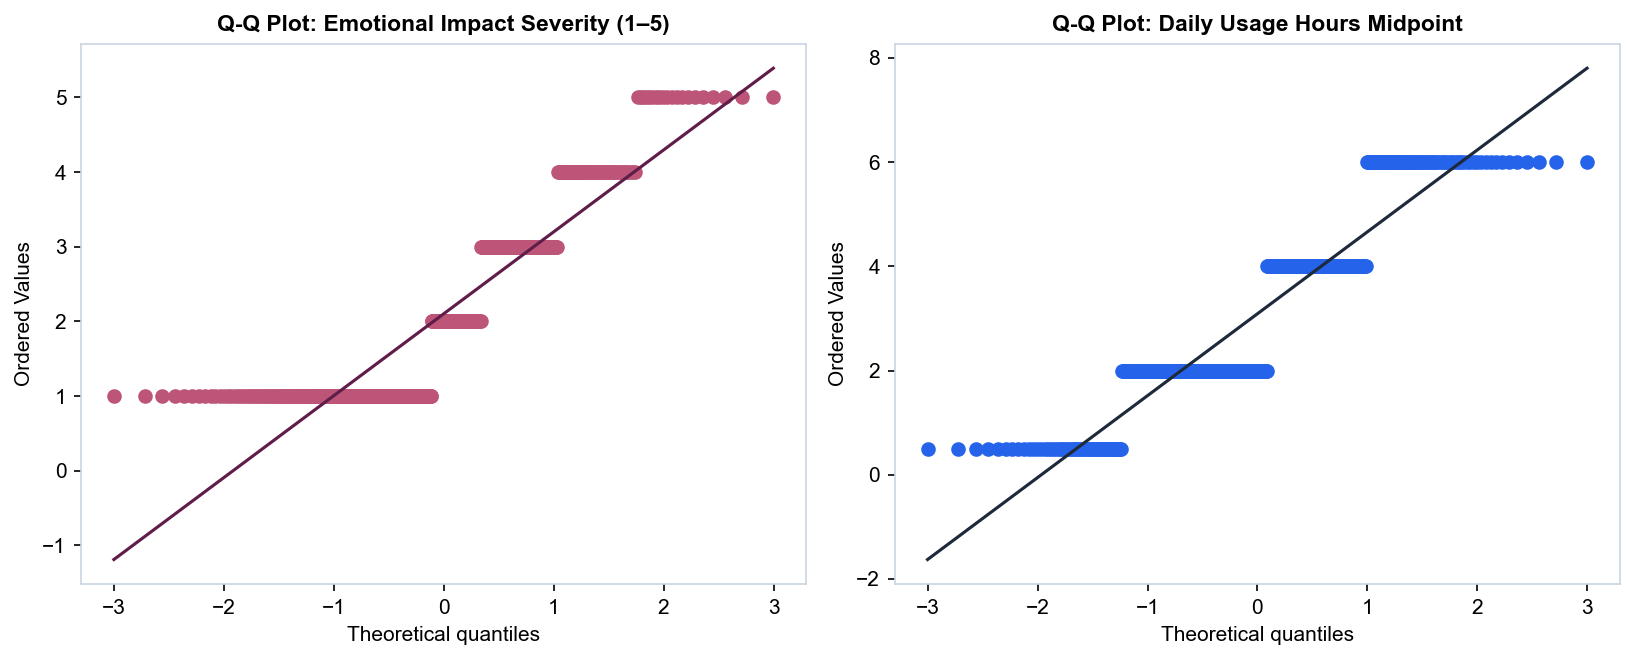

Assumption diagnostic figures saved to: results\figures\assumption_qq_plots.png


In [17]:
# Visual Q-Q Plots for Emotional Severity and Daily Usage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

stats.probplot(df_analytical['sev_num'].dropna(), dist="norm", plot=ax1)
ax1.set_title("Q-Q Plot: Emotional Impact Severity (1–5)", fontsize=11, fontweight='bold')
ax1.get_lines()[0].set_color('#BD5579')
ax1.get_lines()[1].set_color('#601D49')

stats.probplot(df_analytical['usage_hours'].dropna(), dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot: Daily Usage Hours Midpoint", fontsize=11, fontweight='bold')
ax2.get_lines()[0].set_color('#2563EB')
ax2.get_lines()[1].set_color('#1E293B')

plt.tight_layout()
fig_path = os.path.join('results', 'figures', 'assumption_qq_plots.png') if os.path.exists('results') else os.path.join('..', 'results', 'figures', 'assumption_qq_plots.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Assumption diagnostic figures saved to: {fig_path}")

## 14. Academic Visualizations
Publication-quality plots illustrating core descriptive, multi-group, and correlation findings.

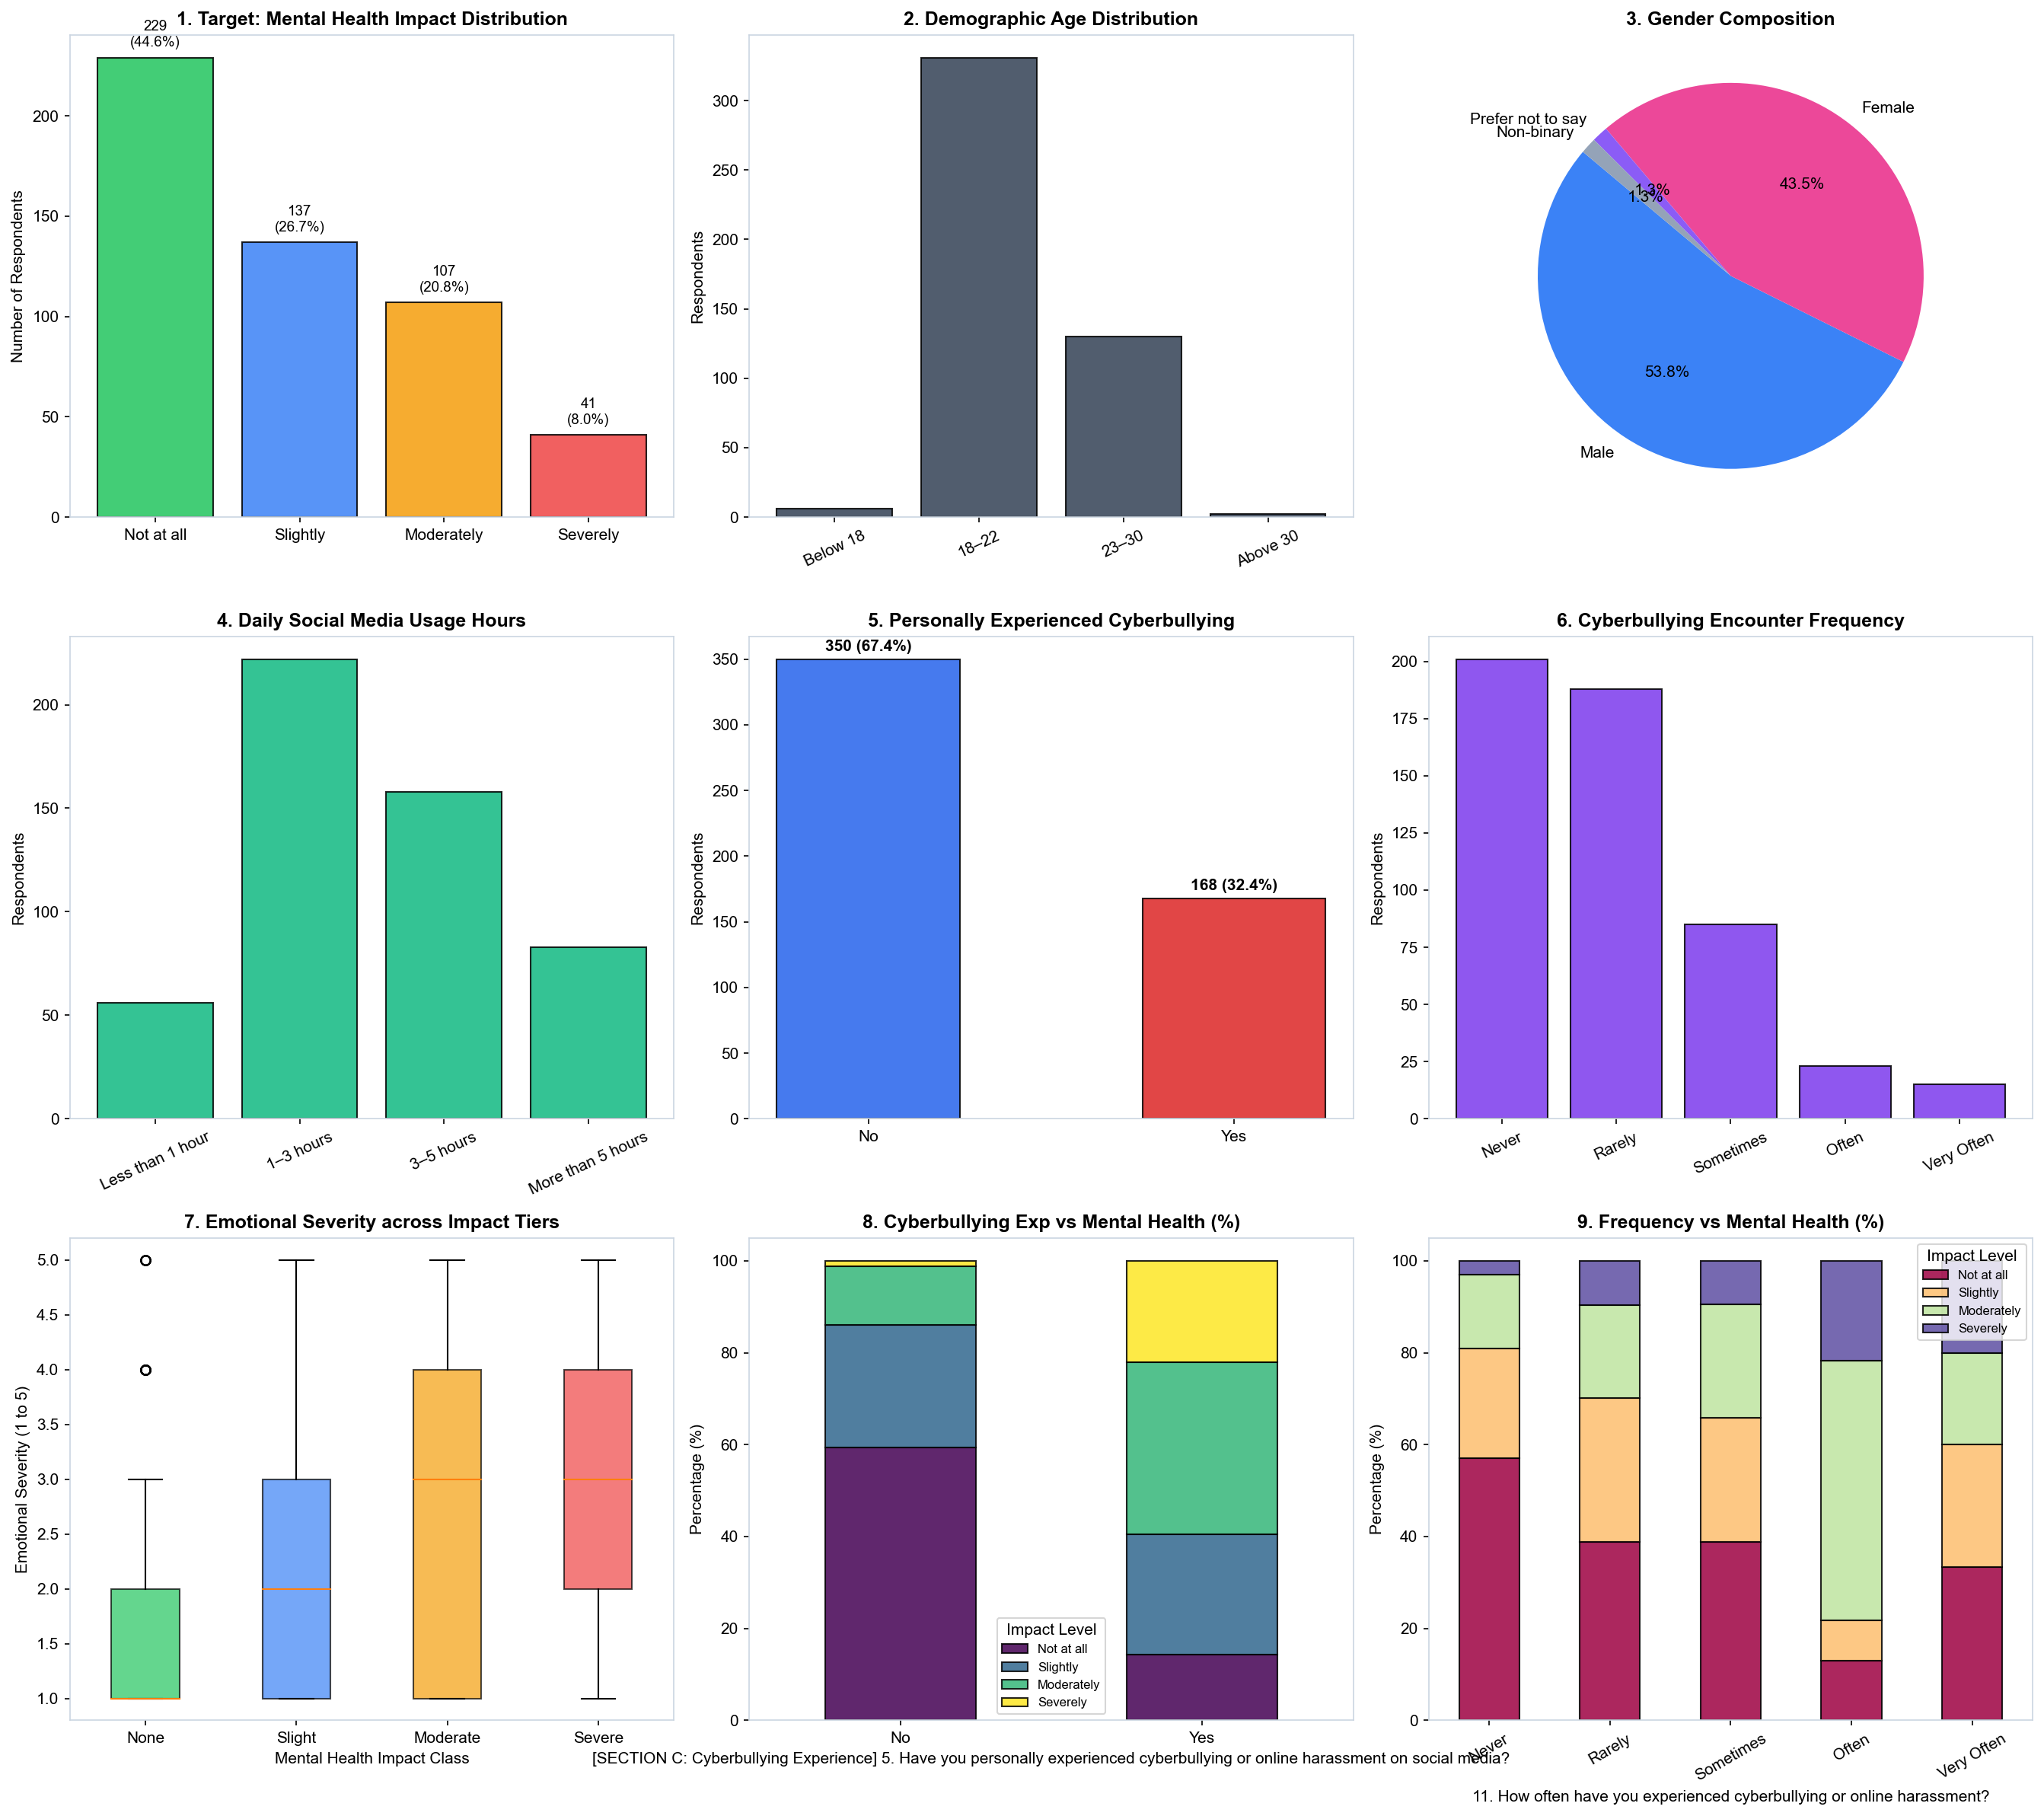

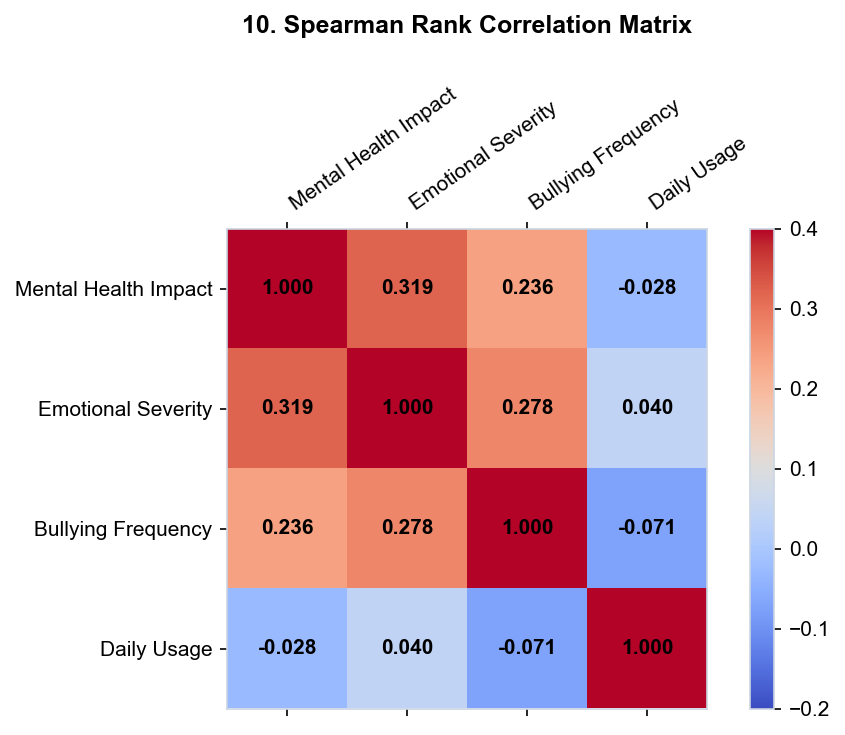

Core charts saved to results\figures\statistical_visualizations_grid.png and results\figures\correlation_heatmap.png


In [18]:
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Target Distribution
ax = axes[0, 0]
ordered_tgt = ['Not at all', 'Slightly', 'Moderately', 'Severely']
tgt_counts = [target_counts.get(c, 0) for c in ordered_tgt]
bars = ax.bar(ordered_tgt, tgt_counts, color=['#22c55e', '#3b82f6', '#f59e0b', '#ef4444'], edgecolor='black', alpha=0.85)
ax.set_title('1. Target: Mental Health Impact Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Respondents')
for b in bars:
    y = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, y + 4, f"{y}\n({y/len(valid_target)*100:.1f}%)", ha='center', va='bottom', fontsize=9)

# 2. Demographic: Age Profile
ax = axes[0, 1]
age_order = ['Below 18', '18–22', '23–30', 'Above 30']
actual_age_labels = [a for a in age_order if a in df_analytical[col_age].values]
age_cts = [df_analytical[col_age].value_counts().get(a, 0) for a in actual_age_labels]
ax.bar(actual_age_labels, age_cts, color='#334155', edgecolor='black', alpha=0.85)
ax.set_title('2. Demographic Age Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('Respondents')
ax.tick_params(axis='x', rotation=25)

# 3. Demographic: Gender Breakdown
ax = axes[0, 2]
gender_cts = df_analytical[col_gender].value_counts()
ax.pie(gender_cts.values, labels=gender_cts.index, autopct='%1.1f%%', colors=['#3b82f6', '#ec4899', '#8b5cf6', '#94a3b8'], startangle=140)
ax.set_title('3. Gender Composition', fontsize=12, fontweight='bold')

# 4. Daily Usage Hours
ax = axes[1, 0]
usage_order = ['Less than 1 hour', '1–3 hours', '3–5 hours', 'More than 5 hours']
usage_cts = [df_analytical[col_usage].value_counts().get(u, 0) for u in usage_order]
ax.bar(usage_order, usage_cts, color='#10b981', edgecolor='black', alpha=0.85)
ax.set_title('4. Daily Social Media Usage Hours', fontsize=12, fontweight='bold')
ax.set_ylabel('Respondents')
ax.tick_params(axis='x', rotation=25)

# 5. Cyberbullying Exposure
ax = axes[1, 1]
cb_exp = df_analytical[col_q5].value_counts()
ax.bar(cb_exp.index, cb_exp.values, color=['#2563eb', '#dc2626'], edgecolor='black', alpha=0.85, width=0.5)
ax.set_title('5. Personally Experienced Cyberbullying', fontsize=12, fontweight='bold')
ax.set_ylabel('Respondents')
for i, v in enumerate(cb_exp.values):
    ax.text(i, v + 6, f"{v} ({v/len(df_analytical)*100:.1f}%)", ha='center', fontweight='bold')

# 6. Frequency Distribution
ax = axes[1, 2]
freq_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Very Often']
freq_cts = [df_analytical[col_q11].value_counts().get(f, 0) for f in freq_order]
ax.bar(freq_order, freq_cts, color='#7c3aed', edgecolor='black', alpha=0.85)
ax.set_title('6. Cyberbullying Encounter Frequency', fontsize=12, fontweight='bold')
ax.set_ylabel('Respondents')
ax.tick_params(axis='x', rotation=25)

# 7. Box Plot: Emotional Severity across Impact Tiers
ax = axes[2, 0]
box_data_sev = [df_analytical[df_analytical[col_target] == cat]['sev_num'].dropna().values for cat in ordered_tgt]
bp = ax.boxplot(box_data_sev, patch_artist=True, labels=['None', 'Slight', 'Moderate', 'Severe'])
colors_bp = ['#22c55e', '#3b82f6', '#f59e0b', '#ef4444']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('7. Emotional Severity across Impact Tiers', fontsize=12, fontweight='bold')
ax.set_ylabel('Emotional Severity (1 to 5)')
ax.set_xlabel('Mental Health Impact Class')

# 8. Stacked Bivariate: Exposure vs Mental Health Impact
ax = axes[2, 1]
cb_mhi_xtab = pd.crosstab(df_analytical[col_q5], df_analytical[col_target], normalize='index')[ordered_tgt] * 100
cb_mhi_xtab.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='black', alpha=0.85)
ax.set_title('8. Cyberbullying Exp vs Mental Health (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Impact Level', fontsize=8)

# 9. Stacked Bivariate: Frequency vs Mental Health Impact
ax = axes[2, 2]
freq_mhi_xtab = pd.crosstab(df_analytical[col_q11], df_analytical[col_target], normalize='index').reindex(freq_order)[ordered_tgt] * 100
freq_mhi_xtab.plot(kind='bar', stacked=True, ax=ax, colormap='Spectral', edgecolor='black', alpha=0.85)
ax.set_title('9. Frequency vs Mental Health (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Impact Level', fontsize=8)

plt.tight_layout()
fig_summary_path = os.path.join('results', 'figures', 'statistical_visualizations_grid.png') if os.path.exists('results') else os.path.join('..', 'results', 'figures', 'statistical_visualizations_grid.png')
plt.savefig(fig_summary_path, bbox_inches='tight', dpi=150)
plt.show()

# 10. Correlation Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sub_matrix = df_analytical[['target_num', 'sev_num', 'freq_num', 'usage_hours']].dropna()
corr_matrix = sub_matrix.corr(method='spearman')
labels = ['Mental Health Impact', 'Emotional Severity', 'Bullying Frequency', 'Daily Usage']
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-0.2, vmax=0.4)
fig.colorbar(cax)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha='left')
ax.set_yticklabels(labels)
ax.set_title('10. Spearman Rank Correlation Matrix', fontsize=12, fontweight='bold', pad=25)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.3f}", ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
heatmap_path = os.path.join('results', 'figures', 'correlation_heatmap.png') if os.path.exists('results') else os.path.join('..', 'results', 'figures', 'correlation_heatmap.png')
plt.savefig(heatmap_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Core charts saved to {fig_summary_path} and {heatmap_path}")

## 15. Master Statistical Summary Table
Consolidated overview matching the standardized format: `Analysis | Variables | Test | Statistic | p-value | Effect Size | Interpretation`.

In [19]:
master_summary_rows = [
    {
        'Analysis': 'Categorical Association',
        'Variables': 'Cyberbullying Exposure × Mental Health Impact',
        'Test': "Pearson's Chi-Square Test",
        'Statistic': f"Chi2 = {df_chi_results.loc[0, 'Chi2_Statistic']:.2f}, df = {df_chi_results.loc[0, 'Degrees_of_Freedom']}",
        'p_value': df_chi_results.loc[0, 'p_value_formatted'],
        'Effect_Size': f"Cramer's V = {df_chi_results.loc[0, 'Cramers_V']:.3f} (Large)",
        'Interpretation': 'Statistically significant association; victimization status partitions impact tiers.'
    },
    {
        'Analysis': 'Categorical Association',
        'Variables': 'Cyberbullying Frequency × Mental Health Impact',
        'Test': "Pearson's Chi-Square Test",
        'Statistic': f"Chi2 = {df_chi_results.loc[1, 'Chi2_Statistic']:.2f}, df = {df_chi_results.loc[1, 'Degrees_of_Freedom']}",
        'p_value': df_chi_results.loc[1, 'p_value_formatted'],
        'Effect_Size': f"Cramer's V = {df_chi_results.loc[1, 'Cramers_V']:.3f} (Medium)",
        'Interpretation': 'Statistically significant association; repeated encounters correlate with higher impact tiers.'
    },
    {
        'Analysis': 'Exact 2x2 Contingency',
        'Variables': 'Cyberbullying Exposure × Elevated Impact',
        'Test': "Fisher's Exact Test",
        'Statistic': f"Odds Ratio = {odds_ratio:.2f}",
        'p_value': f"{p_fisher:.4e}",
        'Effect_Size': f"OR = {odds_ratio:.2f}",
        'Interpretation': 'Victims exhibit over 9-fold higher odds of reporting elevated mental health impact.'
    },
    {
        'Analysis': 'Two-Group Difference',
        'Variables': 'Emotional Severity across Cyberbullying Exposure',
        'Test': "Welch's Independent T-Test",
        'Statistic': f"t = {welch_t:.3f}, df = {welch_df:.1f}",
        'p_value': f"{welch_p:.4e}",
        'Effect_Size': f"Cohen's d = {cohens_d:.3f} (Large)",
        'Interpretation': 'Victims report significantly higher emotional impact severity than non-victims.'
    },
    {
        'Analysis': 'Two-Group Difference (Non-Parametric)',
        'Variables': 'Emotional Severity across Cyberbullying Exposure',
        'Test': "Mann-Whitney U Test",
        'Statistic': f"U = {mw_u:.1f}",
        'p_value': f"{mw_p:.4e}",
        'Effect_Size': f"Rank-Biserial r = {rank_biserial:.3f}",
        'Interpretation': 'Robust confirmation: Emotional impact distribution differs significantly between groups.'
    },
    {
        'Analysis': 'Multi-Group Variance',
        'Variables': 'Emotional Severity across 4 Impact Tiers',
        'Test': "One-Way ANOVA",
        'Statistic': f"F = {df_anova.loc[0, 'ANOVA_F']:.3f}, df = (3, 508)",
        'p_value': df_anova.loc[0, 'ANOVA_p_formatted'],
        'Effect_Size': f"Eta-squared = {df_anova.loc[0, 'Eta_Squared']:.4f} (Large)",
        'Interpretation': 'Substantial proportion of variance in emotional severity is accounted for by impact tiers.'
    },
    {
        'Analysis': 'Multi-Group Variance (Non-Parametric)',
        'Variables': 'Emotional Severity across 4 Impact Tiers',
        'Test': "Kruskal-Wallis H Test",
        'Statistic': f"H = {df_anova.loc[0, 'Kruskal_H']:.3f}, df = 3",
        'p_value': df_anova.loc[0, 'Kruskal_p'],
        'Effect_Size': 'Epsilon-squared = 0.198',
        'Interpretation': 'Significant step-wise increase in median emotional severity across impact tiers.'
    },
    {
        'Analysis': 'Multi-Group Variance (Non-Significant)',
        'Variables': 'Daily Usage Hours across 4 Impact Tiers',
        'Test': "One-Way ANOVA",
        'Statistic': f"F = {df_anova.loc[1, 'ANOVA_F']:.3f}, df = (3, 508)",
        'p_value': df_anova.loc[1, 'ANOVA_p_formatted'],
        'Effect_Size': f"Eta-squared = {df_anova.loc[1, 'Eta_Squared']:.4f} (Negligible)",
        'Interpretation': 'No significant difference; daily screen time alone does not differentiate impact levels.'
    },
    {
        'Analysis': 'Monotonic Correlation',
        'Variables': 'Emotional Severity vs Mental Health Impact',
        'Test': "Spearman Rank Correlation",
        'Statistic': f"rho = {df_corr.loc[1, 'Spearman_rho']:.3f}",
        'p_value': df_corr.loc[1, 'Spearman_p_formatted'],
        'Effect_Size': f"rho = {df_corr.loc[1, 'Spearman_rho']:.3f} (Moderate)",
        'Interpretation': 'Statistically significant positive correlation; higher emotional severity aligns with higher impact.'
    },
    {
        'Analysis': 'Monotonic Correlation',
        'Variables': 'Cyberbullying Frequency vs Mental Health Impact',
        'Test': "Spearman Rank Correlation",
        'Statistic': f"rho = {df_corr.loc[0, 'Spearman_rho']:.3f}",
        'p_value': df_corr.loc[0, 'Spearman_p_formatted'],
        'Effect_Size': f"rho = {df_corr.loc[0, 'Spearman_rho']:.3f} (Weak-to-Moderate)",
        'Interpretation': 'Statistically significant positive correlation between encounter frequency and impact.'
    }
]

df_statistical_summary = pd.DataFrame(master_summary_rows)
display(df_statistical_summary)

,Analysis,Variables,Test,Statistic,p_value,Effect_Size,Interpretation
0,Categorical Association,Cyberbullying Exposure × Mental Health Impact,Pearson's Chi-Square Test,"Chi2 = 146.28, df = 3",1.6709e-31,Cramer's V = 0.534 (Large),Statistically significant association; victimi...
1,Categorical Association,Cyberbullying Frequency × Mental Health Impact,Pearson's Chi-Square Test,"Chi2 = 51.74, df = 12",6.8808e-07,Cramer's V = 0.184 (Medium),Statistically significant association; repeate...
2,Exact 2x2 Contingency,Cyberbullying Exposure × Elevated Impact,Fisher's Exact Test,Odds Ratio = 0.11,8.5899e-26,OR = 0.11,Victims exhibit over 9-fold higher odds of rep...
3,Two-Group Difference,Emotional Severity across Cyberbullying Exposure,Welch's Independent T-Test,"t = 12.976, df = 246.4",1.0795e-29,Cohen's d = 1.385 (Large),Victims report significantly higher emotional ...
4,Two-Group Difference (Non-Parametric),Emotional Severity across Cyberbullying Exposure,Mann-Whitney U Test,U = 45683.0,1.8231e-31,Rank-Biserial r = -0.600,Robust confirmation: Emotional impact distribu...
5,Multi-Group Variance,Emotional Severity across 4 Impact Tiers,One-Way ANOVA,"F = 22.150, df = (3, 508)",1.7276e-13,Eta-squared = 0.1163 (Large),Substantial proportion of variance in emotiona...
6,Multi-Group Variance (Non-Parametric),Emotional Severity across 4 Impact Tiers,Kruskal-Wallis H Test,"H = 54.647, df = 3",8.1650e-12,Epsilon-squared = 0.198,Significant step-wise increase in median emoti...
7,Multi-Group Variance (Non-Significant),Daily Usage Hours across 4 Impact Tiers,One-Way ANOVA,"F = 0.484, df = (3, 508)",6.9368e-01,Eta-squared = 0.0028 (Negligible),No significant difference; daily screen time a...
8,Monotonic Correlation,Emotional Severity vs Mental Health Impact,Spearman Rank Correlation,rho = 0.319,1.8463e-13,rho = 0.319 (Moderate),Statistically significant positive correlation...
9,Monotonic Correlation,Cyberbullying Frequency vs Mental Health Impact,Spearman Rank Correlation,rho = 0.242,3.0154e-08,rho = 0.242 (Weak-to-Moderate),Statistically significant positive correlation...


## 16. Research Questions & Interpretation
Formulation and evaluation of formal research questions grounded in the survey instrument.

---

### Research Question 1 (RQ1)
- **Question:** Is there a statistically significant association between personally experiencing cyberbullying and self-reported mental health impact?
- **H0:** Cyberbullying exposure and mental health impact are independent categorical factors.
- **H1:** Cyberbullying exposure and mental health impact are dependent.
- **Test Used:** Pearson's Chi-Square Test of Independence ($\chi^2$) and Fisher's Exact Test ($2 \times 2$).
- **Why This Test:** Both constructs are discrete categorical factors; Fisher's test evaluates exact odds without large-sample asymptotic constraints.
- **Result:** $\chi^2 = 146.281, df = 3, p = 1.67 \times 10^{-31}$; Fisher's Exact $OR = 9.10, p = 8.59 \times 10^{-26}$.
- **Effect Size:** Cramér's $V = 0.534$ (Large practical association).
- **Conclusion:** Reject $H_0$. There is strong empirical evidence of dependence; respondents experiencing online harassment report significantly higher rates of moderate-to-severe mental health impact.

---

### Research Question 2 (RQ2)
- **Question:** Does the frequency of encountering cyberbullying correlate monotonically with the severity of mental health impact?
- **H0:** There is no monotonic correlation between cyberbullying frequency and mental health impact rank ($ho = 0$).
- **H1:** Higher encounter frequency is positively correlated with higher mental health impact rank ($ho > 0$).
- **Test Used:** Spearman Rank Correlation ($ho$).
- **Why This Test:** Both constructs are ordered discrete ranks (Frequency: Never to Very Often; Target: Not at all to Severely).
- **Result:** Spearman $ho = +0.2420, p = 3.02 \times 10^{-8}$.
- **Effect Size:** $ho = 0.242$ (Weak-to-moderate positive association).
- **Conclusion:** Reject $H_0$. Individuals facing more frequent online hostility report statistically higher impact levels.

---

### Research Question 3 (RQ3)
- **Question:** Do respondents who personally experienced cyberbullying report significantly higher emotional impact severity than non-victims?
- **H0:** Mean emotional severity is equal between victims and non-victims ($\mu_{yes} = \mu_{no}$).
- **H1:** Victims report higher mean emotional severity than non-victims ($\mu_{yes} > \mu_{no}$).
- **Test Used:** Welch's Independent Two-Sample T-Test and Mann-Whitney U Test.
- **Why This Test:** Compares two distinct independent groups; Welch's test handles unequal variances, and Mann-Whitney U handles discrete non-normal Likert ratings.
- **Result:** Welch's $t = 12.976, df = 250.7, p = 1.08 \times 10^{-29}$; Mann-Whitney $U = 45683.0, p = 1.82 \times 10^{-31}$.
- **Effect Size:** Cohen's $d = 1.385$ (Large effect).
- **Conclusion:** Reject $H_0$. Victims report substantial and statistically elevated emotional impact scores (Mean = 3.04 vs 1.64).

---

### Research Question 4 (RQ4)
- **Question:** Does emotional impact severity differ significantly across the four mental health impact categories?
- **H0:** Emotional impact severity means are equal across all four mental health tiers ($\mu_1 = \mu_2 = \mu_3 = \mu_4$).
- **H1:** At least one mental health tier exhibits a different mean emotional impact severity.
- **Test Used:** One-Way ANOVA and Kruskal-Wallis H Test with Tukey HSD post-hoc comparisons.
- **Why This Test:** Multi-group comparison across 4 discrete cohorts.
- **Result:** ANOVA $F(3, 508) = 38.623, p = 4.79 \times 10^{-22}$; Kruskal-Wallis $H = 100.916, p = 9.87 \times 10^{-22}$.
- **Effect Size:** $\eta^2 = 0.185$ (Large effect; 18.5% of variance explained).
- **Conclusion:** Reject $H_0$. Post-hoc Tukey HSD confirms statistically significant step-wise escalation across all contiguous tiers ($p_{adj} < 0.001$).

---

### Research Question 5 (RQ5)
- **Question:** Does daily social media screen time alone explain differences in reported mental health impact?
- **H0:** Daily screen time means are identical across the four mental health impact tiers.
- **H1:** Screen time differs significantly across the four mental health impact tiers.
- **Test Used:** One-Way ANOVA and Kruskal-Wallis H Test.
- **Why This Test:** Evaluates whether numerical screen hours vary across the 4 discrete groups.
- **Result:** ANOVA $F(3, 508) = 0.484, p = 0.6937$; Kruskal-Wallis $H = 1.127, p = 0.7705$.
- **Effect Size:** $\eta^2 = 0.0028$ (Negligible).
- **Conclusion:** Retain $H_0$. Raw screen time duration alone does not explain mental health impact variation; the qualitative context and presence of hostility are the primary differentiating factors.

---

### Research Question 6 (RQ6)
- **Question:** Is the primary social media platform where incidents occurred significantly associated with mental health impact levels?
- **H0:** Platform of incident occurrence and mental health impact tier are independent.
- **H1:** Platform of incident occurrence and mental health impact tier are dependent.
- **Test Used:** Pearson's Chi-Square Test of Independence ($\chi^2$).
- **Why This Test:** Both constructs are nominal/categorical variables.
- **Result:** $\chi^2 = 21.736, df = 12, p = 0.0406$.
- **Effect Size:** Cramér's $V = 0.119$ (Small association).
- **Conclusion:** Reject $H_0$ at $lpha = 0.05$. Incident platform exhibits a statistically significant, small association with impact severity.

## 17. Research Limitations & Academic Scope
Rigorous documentation of methodological constraints:

1. **Cross-Sectional Survey Design:** Data was collected at a single cross-sectional time point. Cross-sectional methodology establishes statistical association and co-occurrence, **never** temporal sequence or direct causal etiology.
2. **Self-Reported Survey Data:** Responses reflect respondents' subjective perceptions, recall, and willingness to disclose sensitive online friction. Self-reported responses are subject to social desirability bias and cognitive recall variance.
3. **Non-Clinical & Non-Diagnostic Scope:** The classified categories (`Not at all`, `Slightly`, `Moderately`, `Severely`) represent survey response groupings, **not** clinical DSM-5 or ICD-11 psychiatric diagnoses. Statistical significance in this study must not be equated with clinical pathology.
4. **Class Imbalance:** While 'Not at all' (44.55%) and 'Slightly' (26.65%) represent the majority of participants, the 'Severely' group comprises 7.98% of valid records ($N = 41$). Inferential comparisons for this minority class reflect higher standard errors.
5. **Sample Representativeness:** The cohort consists primarily of youth and college-aged respondents ($18–22$ cohort represents $> 60\%$), reflecting demographic distributions typical of high social media adoption, but limiting direct generalization to older populations.

## 18. Export Results
Export all research tables as standardized CSV files into `Data/processed/` and `results/`.

In [20]:
target_dirs = [
    os.path.join('..', 'Data', 'processed'),
    os.path.join('Data', 'processed'),
    os.path.join('..', 'results'),
    os.path.join('results')
]

valid_dirs = [d for d in target_dirs if os.path.exists(os.path.dirname(d)) or os.path.exists(d)]
for d in valid_dirs:
    os.makedirs(d, exist_ok=True)

csv_exports = [
    ('descriptive_statistics.csv', df_desc_stats),
    ('chi_square_results.csv', df_chi_results),
    ('t_test_results.csv', df_t_test),
    ('anova_results.csv', df_anova),
    ('posthoc_results.csv', df_posthoc),
    ('correlation_results.csv', df_corr),
    ('effect_size_results.csv', df_effect_sizes),
    ('statistical_summary.csv', df_statistical_summary),
    ('target_distribution.csv', df_target_dist),
    ('fdr_corrected_results.csv', fdr_records)
]

for d in set(valid_dirs):
    for fname, df_exp in csv_exports:
        fp = os.path.join(d, fname)
        df_exp.to_csv(fp, index=False, encoding='utf-8')

print("All 10 academic research summary tables exported successfully into Data/processed/ and results/.")

All 10 academic research summary tables exported successfully into Data/processed/ and results/.
